In [1]:
# /home/admin/LLM/LLM/01/web/notebooks/analysis.ipynb

import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

# Single imports per library
from src.visualizer import RAGVisualizer
import pandas as pd

# Initialize once
viz = RAGVisualizer()
df = viz.load_selected_experiments(viz.get_experiment_registry()['filename'].tolist())

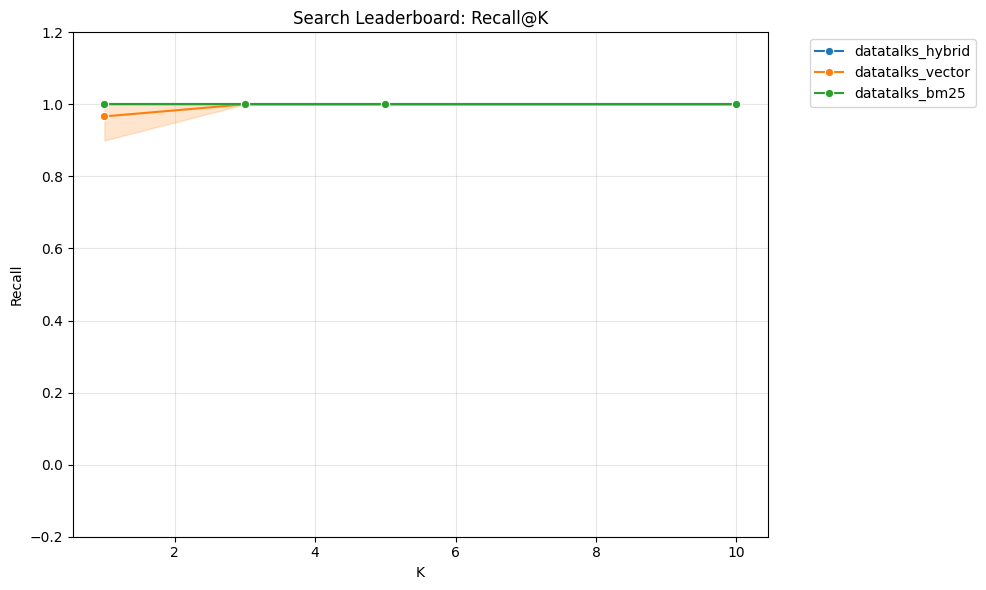

,recall@5,mrr,precision@5,hit_rate@5,unique_courses@5,entropy@5,p95_latency_ms
run_label,,,,,,,
datatalks_bm25,1.0,1.0,1.0,1.0,1,-0.0,3.6520
datatalks_hybrid,1.0,1.0,1.0,1.0,1,-0.0,27.6905
datatalks_vector,1.0,1.0,1.0,1.0,1,-0.0,22.8170


expected_course,datatalks-zoomcamp
run_label,
datatalks_bm25,1.0
datatalks_hybrid,1.0
datatalks_vector,1.0


run_label
datatalks_bm25      0.0
datatalks_hybrid    0.0
datatalks_vector    0.0
dtype: float64

run_label
datatalks_bm25      1.0
datatalks_hybrid    1.0
datatalks_vector    1.0
Name: success, dtype: float64

k,1,3,5,10
run_label,,,,
datatalks_bm25,3.183333,2.859667,3.053,4.449
datatalks_hybrid,22.957333,24.037000,24.777,30.136
datatalks_vector,20.711667,19.516333,19.615,23.662


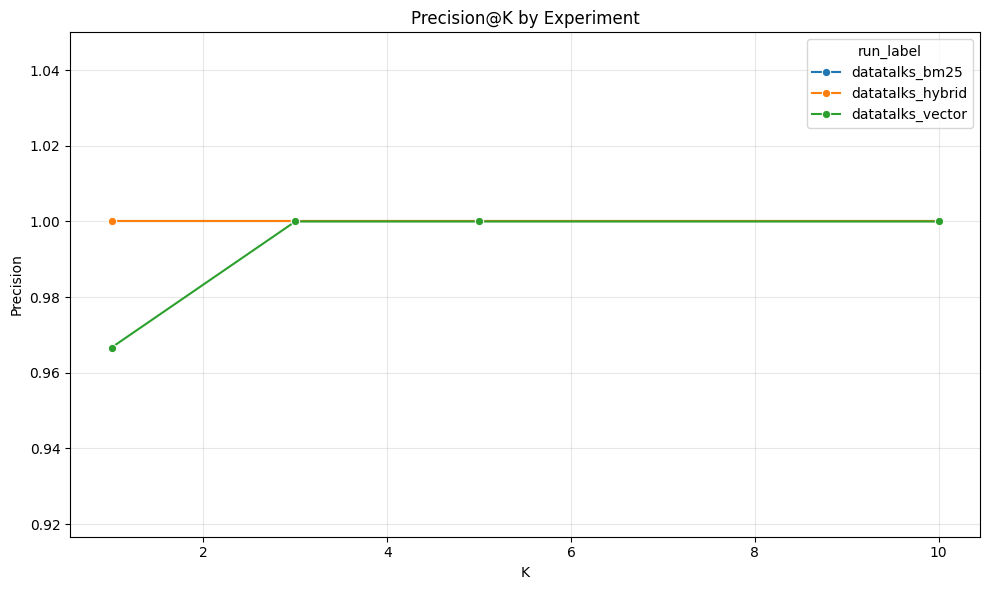

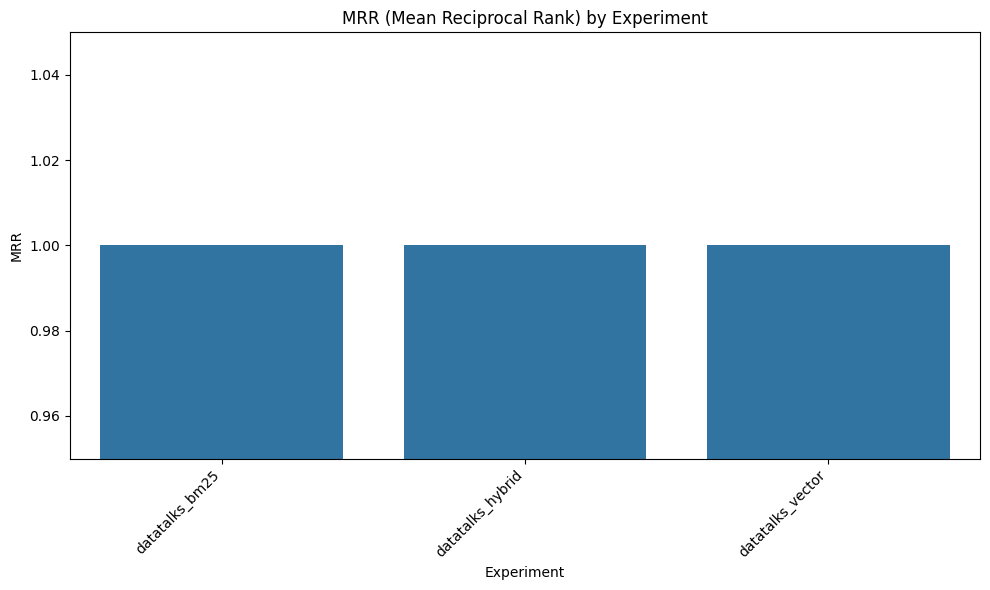

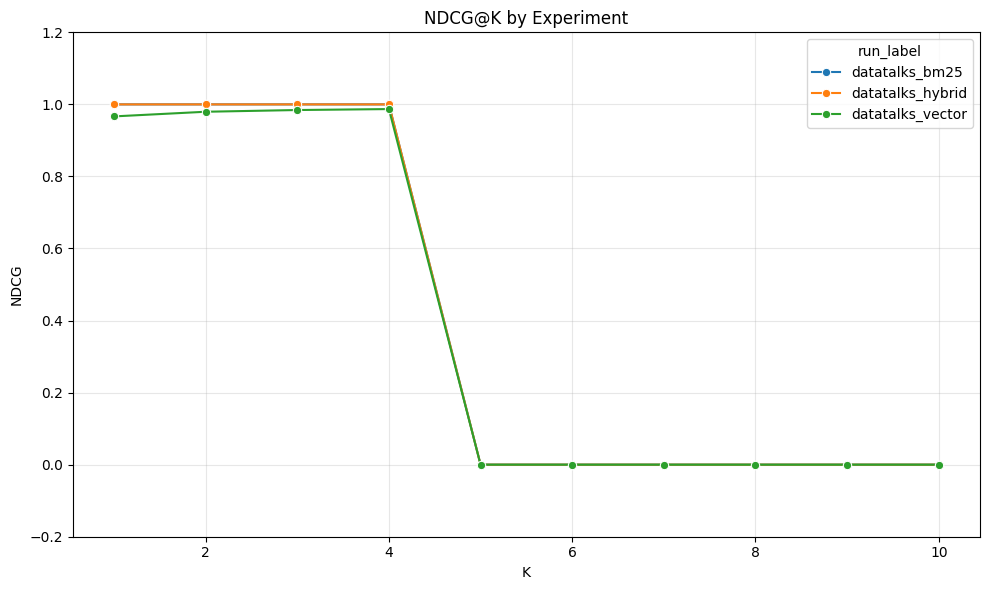

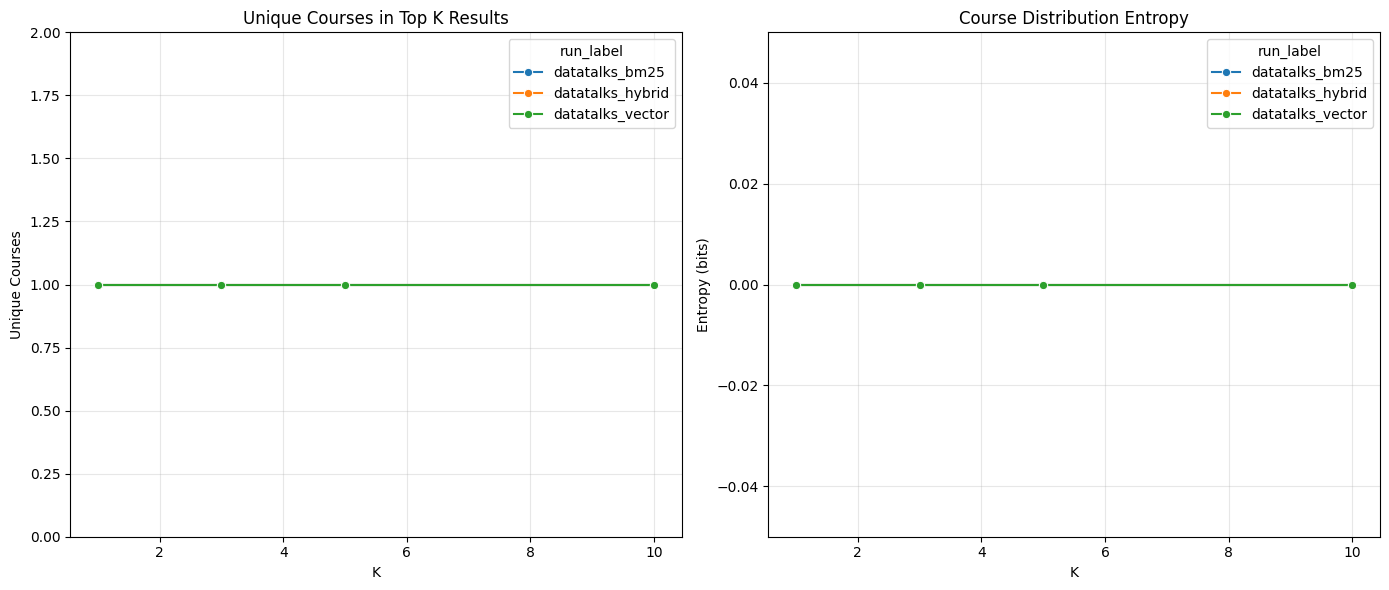

In [2]:
# 1. Leaderboard (Recall@K)
viz.plot_leaderboard(df)

# 2. Comprehensive summary
summary = viz.get_comprehensive_summary(df)
display(summary)

# 3. Recall by course at K=5
recall_by_course = df[df['k'] == 5].groupby(['run_label', 'expected_course'])['success'].mean().unstack()
display(recall_by_course)

# 4. Cross-course rate
cross_rate = (df[df['k'] == 5].groupby('run_label').apply(
    lambda g: (g['expected_course'] != g['found_course']).mean()
))
display(cross_rate.sort_values(ascending=False))

# 5. Best configs by recall@5
best = df[df['k'] == 5].groupby('run_label')['success'].mean().sort_values(ascending=False)
display(best)

# 6. Latency comparison
latency = df.groupby(['run_label', 'k'])['latency_ms'].mean().unstack()
display(latency)

# 7. Precision@K
precision = viz.compute_precision_at_k(df)
viz.plot_precision_at_k(precision)

# 8. MRR comparison
mrr = viz.compute_mrr(df)
viz.plot_mrr_comparison(mrr)

# 9. NDCG comparison
ndcg = viz.compute_ndcg(df)
viz.plot_ndcg_comparison(ndcg)

# 10. Diversity metrics
unique = viz.compute_unique_courses_in_top_k(df)
entropy = viz.compute_course_entropy(df)
viz.plot_diversity_metrics(unique, entropy)

In [3]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)
print("=" * 60)
print("SEARCH EVALUATION RESULTS")
print("=" * 60)

# 1. Best configs by recall@5
best = df[df['k'] == 5].groupby('run_label')['success'].mean().sort_values(ascending=False)
print("\n=== BEST CONFIGS BY RECALL@5 ===")
print(best.round(4).to_string())

# 2. Recall by course at K=5
recall_by_course = df[df['k'] == 5].groupby(['run_label', 'expected_course'])['success'].mean().unstack()
print("\n=== RECALL@5 BY COURSE ===")
print(recall_by_course.round(4).to_string())

# 3. Cross-course rate
df['is_cross'] = df['expected_course'] != df['found_course']
cross_rate = df[df['k'] == 5].groupby('run_label')['is_cross'].mean().sort_values(ascending=False)
print("\n=== CROSS-COURSE RATE (K=5) ===")
print(cross_rate.round(4).to_string())

# 4. Average latency by config
latency = df[df['k'] == 5].groupby('run_label')['latency_ms'].mean().sort_values()
print("\n=== AVG LATENCY (ms) at K=5 ===")
print(latency.round(2).to_string())

# 5. Best global config (no filter)
global_configs = [c for c in best.index if c.startswith('global_')]
global_best = best[global_configs]
print("\n=== BEST GLOBAL CONFIGS (No course filter) ===")
print(global_best.round(4).to_string())

# 6. Raw data sample for verification
print("\n=== SAMPLE RESULTS (First 5 DE queries) ===")
de_sample = df[(df['k'] == 5) & (df['expected_course'] == 'data-engineering-zoomcamp')].head(5)
print(de_sample[['query', 'found_course', 'success', 'score']].to_string())

# 7. Summary table
print("\n=== COMPREHENSIVE SUMMARY ===")
summary = viz.get_comprehensive_summary(df)
print(summary.round(4).to_string())

SEARCH EVALUATION RESULTS

=== BEST CONFIGS BY RECALL@5 ===
run_label
datatalks_bm25      1.0
datatalks_hybrid    1.0
datatalks_vector    1.0

=== RECALL@5 BY COURSE ===
expected_course   datatalks-zoomcamp
run_label                           
datatalks_bm25                   1.0
datatalks_hybrid                 1.0
datatalks_vector                 1.0

=== CROSS-COURSE RATE (K=5) ===
run_label
datatalks_bm25      0.0
datatalks_hybrid    0.0
datatalks_vector    0.0

=== AVG LATENCY (ms) at K=5 ===
run_label
datatalks_bm25       3.05
datatalks_vector    19.62
datatalks_hybrid    24.78

=== BEST GLOBAL CONFIGS (No course filter) ===
Series([], )

=== SAMPLE RESULTS (First 5 DE queries) ===
Empty DataFrame
Columns: [query, found_course, success, score]
Index: []

=== COMPREHENSIVE SUMMARY ===
                  recall@5  mrr  precision@5  hit_rate@5  unique_courses@5  entropy@5  p95_latency_ms
run_label                                                                                        